<a href="https://colab.research.google.com/github/RonakkudalAI/Data-Analysis/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/diabetes.csv")
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
number_only = df.select_dtypes(include=["int64", "float64"])

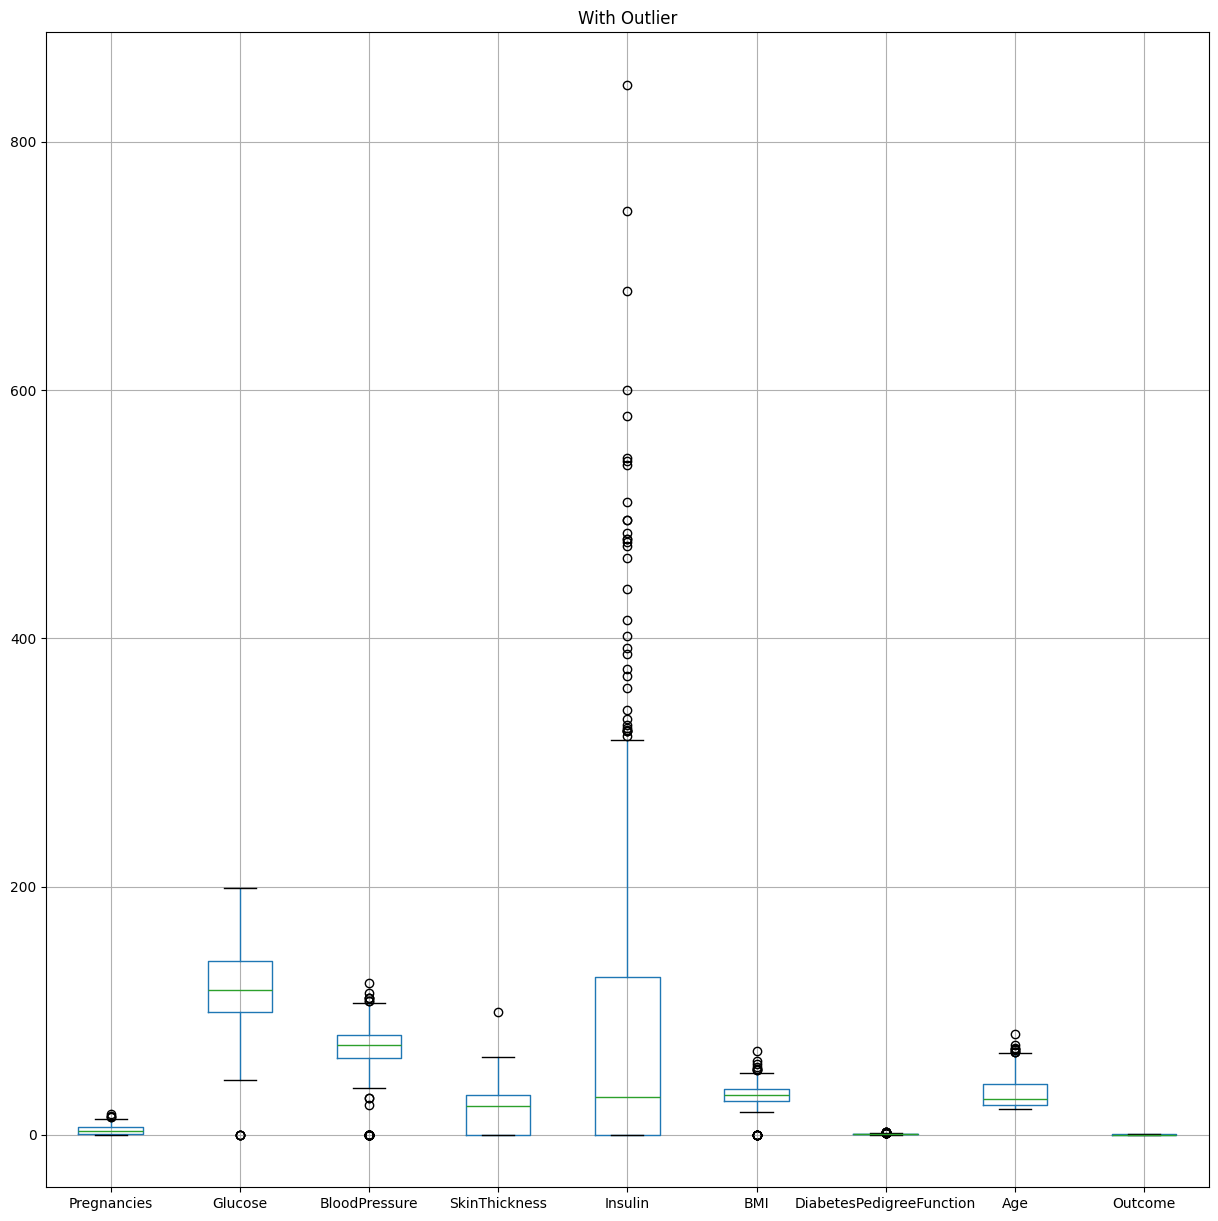

In [ ]:
plt.figure(figsize=(15,15))
number_only.boxplot()
plt.title("With Outlier")
plt.show()

In [ ]:
#Clean Outlier

Q1 = number_only.quantile(0.25)
Q3 = number_only.quantile(0.75)

IQR = Q3-Q1

lower_range = Q1-1.5*IQR
upper_range = Q3+1.5*IQR
df_clean = df[~((number_only<lower_range) | (number_only>upper_range)).any(axis=1)]
print(df_clean)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
5              5      116             74              0        0  25.6   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

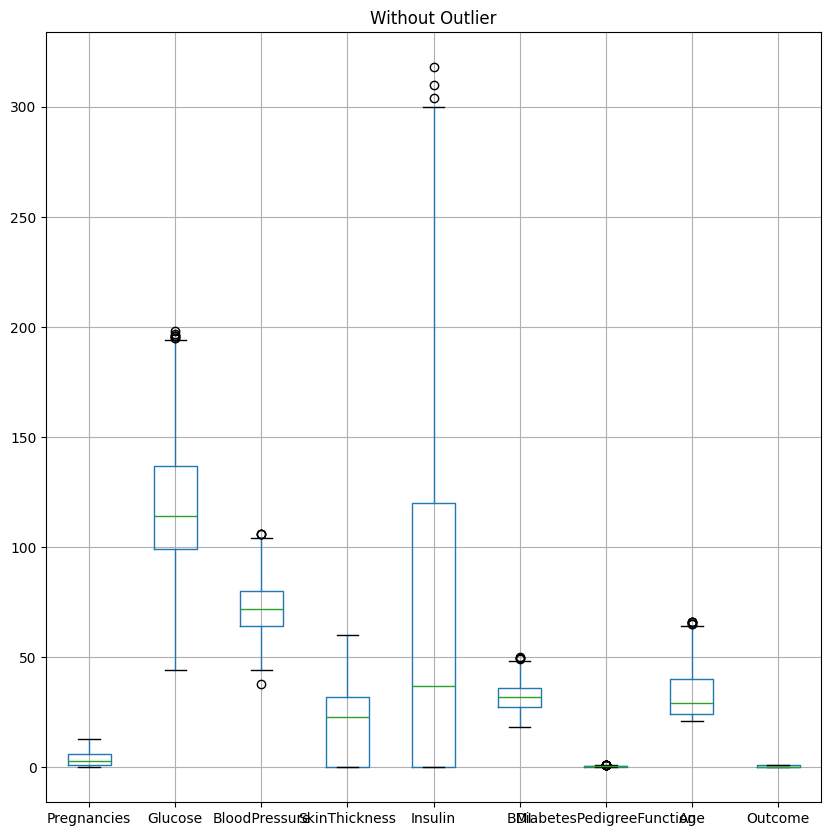

In [ ]:
plt.figure(figsize=(10,10))
df_clean.boxplot()
plt.title("Without Outlier")
plt.show()

In [ ]:
#Clean Outlier

Q1 = number_only.quantile(0.25)
Q3 = number_only.quantile(0.75)

IQR = Q3-Q1

lower_range = Q1-1.5*IQR
upper_range = Q3+1.5*IQR
df_clean = df[~((number_only<lower_range) | (number_only>upper_range)).any(axis=1)]
print(df_clean)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
5              5      116             74              0        0  25.6   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

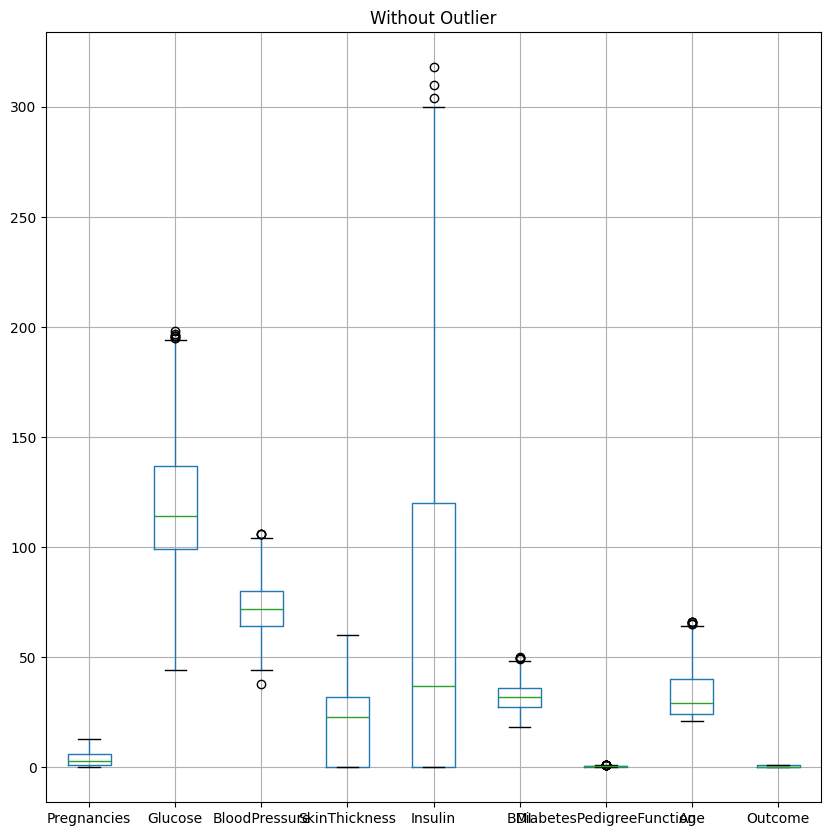

In [ ]:
plt.figure(figsize=(10,10))
df_clean.boxplot()
plt.title("Without Outlier")
plt.show()

In [ ]:
# Find Correlation

df_corr = df_clean.corr()
df_corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.142093,0.210666,-0.094425,-0.114510,0.036958,0.009289,0.567438,0.227987
Glucose,0.142093,1.000000,0.238754,-0.004609,0.248225,0.192504,0.066530,0.286682,0.492740
BloodPressure,0.210666,0.238754,1.000000,0.037388,-0.041513,0.303301,0.024290,0.354036,0.183298
SkinThickness,-0.094425,-0.004609,0.037388,1.000000,0.487566,0.390340,0.148486,-0.143376,0.030676
Insulin,-0.114510,0.248225,-0.041513,0.487566,1.000000,0.188635,0.213191,-0.089535,0.097746
BMI,0.036958,0.192504,0.303301,0.390340,0.188635,1.000000,0.144757,0.063370,0.269371
DiabetesPedigreeFunction,0.009289,0.066530,0.024290,0.148486,0.213191,0.144757,1.000000,0.030081,0.179072
Age,0.567438,0.286682,0.354036,-0.143376,-0.089535,0.063370,0.030081,1.000000,0.263344
Outcome,0.227987,0.492740,0.183298,0.030676,0.097746,0.269371,0.179072,0.263344,1.000000


<Axes: >

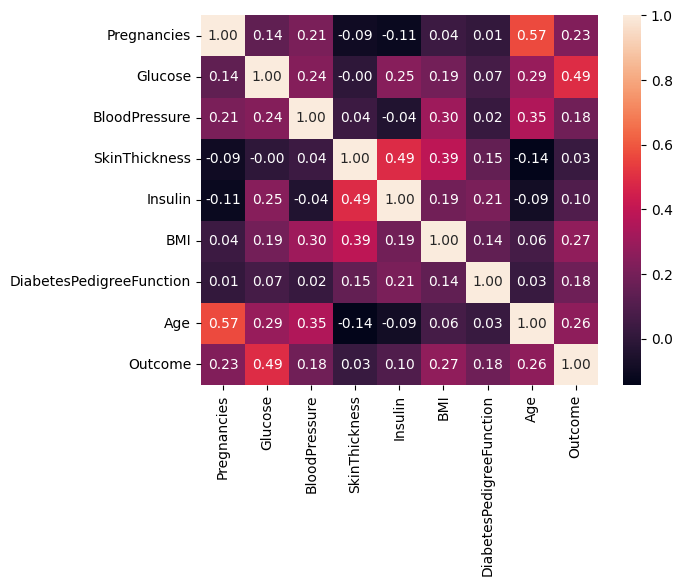

In [ ]:
sns.heatmap(df_corr,annot=True,fmt=".2f")

In [ ]:
# Find Corvariance

df_cov = df_clean.cov()
df_cov

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,10.634087,13.512672,7.796336,-4.723476,-29.712550,0.775429,0.007602,20.503758,0.345021
Glucose,13.512672,850.432425,79.016182,-2.062012,575.985827,36.119253,0.486899,92.637158,6.668440
BloodPressure,7.796336,79.016182,128.792667,6.508808,-37.486987,22.146166,0.069179,44.520268,0.965360
SkinThickness,-4.723476,-2.062012,6.508808,235.315334,595.120359,38.525416,0.571624,-24.370634,0.218376
Insulin,-29.712550,575.985827,-37.486987,595.120359,6331.302461,96.571246,4.257105,-78.941273,3.609360
BMI,0.775429,36.119253,22.146166,38.525416,96.571246,41.395970,0.233732,4.517796,0.804298
DiabetesPedigreeFunction,0.007602,0.486899,0.069179,0.571624,4.257105,0.233732,0.062979,0.083648,0.020855
Age,20.503758,92.637158,44.520268,-24.370634,-78.941273,4.517796,0.083648,122.780819,1.354176
Outcome,0.345021,6.668440,0.965360,0.218376,3.609360,0.804298,0.020855,1.354176,0.215364


<Axes: >

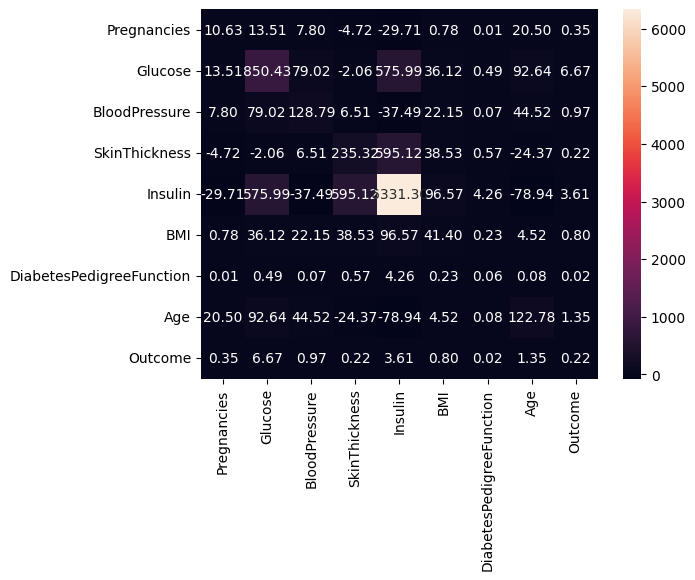

In [ ]:
sns.heatmap(df_cov,annot=True,fmt=".2f")